# 03. Baseline Models

**Input**: `accepted_modeling.parquet` produced by Notebook 02

**Goal**: Establish naive and progressively controlled estimates of the interest rate → default relationship, and quantify how much endogeneity (omitted-variable bias) inflates the naive estimate.

**Models**:
1. **Naive**: `default ~ int_rate` — raw association, no controls
2. **Grade-controlled**: `default ~ int_rate + grade` — partial control for the main confound
3. **Full controls**: `default ~ int_rate + X` — all covariates from Notebook 02
4. **Binary treatment**: `default ~ high_rate + X` — within-grade treatment indicator

**Key question**: How much does the `int_rate` (or `high_rate`) AME (Average Marginal Effect) shrink as controls are added?  
Large shrinkage = large omitted-variable bias in the naive estimate.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

os.chdir("C:/Users/David Cho/OneDrive/Desktop/Projects/credit-risk-causal-analysis")

sns.set_theme(style='whitegrid', font_scale=1.1)

In [7]:
OUTPUT_DIR  = './outputs/intermediate'

mdf = pd.read_parquet(f'{OUTPUT_DIR}/accepted_modeling.parquet')
with open(f'{OUTPUT_DIR}/meta.json') as f:
    meta = json.load(f)
    
COVARIATES = [c for c in meta['COVARIATES'] if c in mdf.columns]

print(f'Modeling dataset: {mdf.shape}')
print(f'Default rate    : {mdf["default"].mean():.4f}')
print(f'Covariates      : {len(COVARIATES)}')

Modeling dataset: (1025917, 29)
Default rate    : 0.2009
Covariates      : 24


## Model 1 — Naive: `default ~ int_rate`

In [9]:
X_naive = sm.add_constant(mdf[['int_rate']])
logit1  = sm.Logit(mdf['default'], X_naive).fit(disp=False)

ame_naive = logit1.get_margeff().summary_frame().loc['int_rate', 'dy/dx']

print('=== MODEL 1: NAIVE ===')
print(logit1.summary2())
print(f'\nAME(int_rate): {ame_naive:.6f}  '
      f'(+1 pp rate → {ame_naive*100:.4f} pp higher P(default) — RAW, NOT CAUSAL)')

=== MODEL 1: NAIVE ===
                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: default          Pseudo R-squared: 0.068      
Date:               2026-04-03 18:43 AIC:              959552.7683
No. Observations:   1025917          BIC:              959576.4505
Df Model:           1                Log-Likelihood:   -4.7977e+05
Df Residuals:       1025915          LL-Null:          -5.1465e+05
Converged:          1.0000           LLR p-value:      0.0000     
No. Iterations:     6.0000           Scale:            1.0000     
-------------------------------------------------------------------
              Coef.   Std.Err.      z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
const        -3.3369    0.0084  -395.1624  0.0000  -3.3534  -3.3203
int_rate      0.1400    0.0005   255.7039  0.0000   0.1389   0.1410


AME(int_rate): 0.020825  (+1 pp rate → 2.0825 pp higher P(

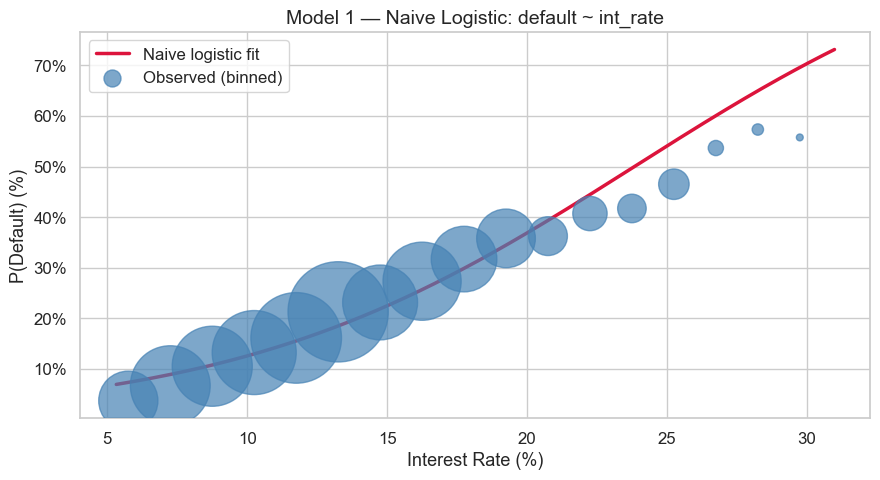

In [11]:
# Visualise naive fitted curve against binned actuals
FIGURE_DIR = './outputs/figures'

rate_grid = np.linspace(mdf['int_rate'].min(), mdf['int_rate'].max(), 200)
p_naive   = logit1.predict(sm.add_constant(pd.DataFrame({'int_rate': rate_grid})))

mdf['_bin'] = pd.cut(mdf['int_rate'], bins=np.arange(5, 32, 1.5), right=False)
binned = mdf.groupby('_bin', observed=True)['default'].agg(['mean','count']).reset_index()
binned['mid'] = binned['_bin'].apply(lambda x: x.mid)
binned = binned[binned['count'] >= 100]
mdf.drop(columns=['_bin'], inplace=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rate_grid, p_naive*100, color='crimson', linewidth=2.5, label='Naive logistic fit')
ax.scatter(binned['mid'], binned['mean']*100,
           s=binned['count']/30, color='steelblue', alpha=0.7,
           label='Observed (binned)', zorder=5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Interest Rate (%)', fontsize=13)
ax.set_ylabel('P(Default) (%)', fontsize=13)
ax.set_title('Model 1 — Naive Logistic: default ~ int_rate', fontsize=14)
leg = ax.legend()
for handle in leg.legend_handles:
    if hasattr(handle, '_sizes'):
        handle._sizes = [150]
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig14_naive_logistic.png', dpi=150, bbox_inches='tight')
plt.show()

## Model 2 — Grade-Controlled: `default ~ int_rate + grade`

In [13]:
X2 = sm.add_constant(pd.concat([mdf[['int_rate']], mdf['grade_num']], axis=1))
logit2 = sm.Logit(mdf['default'], X2).fit(disp=False)

ame_grade = logit2.get_margeff().summary_frame().loc['int_rate', 'dy/dx']

print('=== MODEL 2: GRADE-CONTROLLED ===')
print(logit2.summary2())
print(f'int_rate AME         : {ame_grade:.5f}  ({ame_grade*100:.4f} pp)')

=== MODEL 2: GRADE-CONTROLLED ===
                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: default          Pseudo R-squared: 0.070      
Date:               2026-04-03 18:44 AIC:              957255.4572
No. Observations:   1025917          BIC:              957290.9805
Df Model:           2                Log-Likelihood:   -4.7862e+05
Df Residuals:       1025914          LL-Null:          -5.1465e+05
Converged:          1.0000           LLR p-value:      0.0000     
No. Iterations:     6.0000           Scale:            1.0000     
-------------------------------------------------------------------
              Coef.   Std.Err.      z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
const        -2.7778    0.0143  -194.4765  0.0000  -2.8058  -2.7498
int_rate      0.0549    0.0019    29.5946  0.0000   0.0512   0.0585
grade_num     0.3155    0.0066    47.9024  0.0000

## Model 3 — Full Controls: `default ~ int_rate + X_{-subgrade}`  

In [23]:
# Remove subgrade_num to avoid multicollinearity
high_VIF = ['subgrade_num']
filtered_COVARIATES = [col for col in COVARIATES if col not in high_VIF]
print(f'Cavariate List:\n  {filtered_COVARIATES}')
X3 = sm.add_constant(mdf[['int_rate'] + filtered_COVARIATES].astype(float))

vif_data2 = pd.DataFrame()
vif_data2["feature"] = X3.columns
vif_data2["VIF"] = [variance_inflation_factor(X3.values, i) for i in range(len(X3.columns))]

print(f'\n\nTop 5 VIF: \n  {vif_data2.sort_values(by="VIF", ascending=False).head(5)}')

Cavariate List:
  ['inq_last_6mths', 'revol_bal', 'open_acc', 'log_annual_inc', 'loan_amnt', 'dti', 'total_acc', 'emp_length_num', 'fico_mid', 'revol_util', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_home_asset', 'purpose_medical', 'purpose_other', 'purpose_planned_purchase', 'purpose_small_business', 'term_months_encoded', 'issue_year_encoded', 'ever_delinq', 'grade_num']


Top 5 VIF: 
        feature        VIF
0       const  49.725831
1    int_rate  13.420115
24  grade_num  13.044602
8   total_acc   2.236740
4    open_acc   2.192991


In [25]:
logit3 = sm.Logit(mdf['default'], X3).fit(disp=False, method='lbfgs', maxiter=400)

marg3  = logit3.get_margeff().summary_frame()
ame_full = marg3.loc['int_rate', 'dy/dx'] if 'int_rate' in marg3.index else np.nan

print('\n=== MODEL 3: FULL CONTROLS ===')
print(logit3.summary2())
print(f'int_rate AME       : {ame_full:.5f}  ({ame_full*100:.4f} pp)')
print(f'Naive vs Full AME  : {100 * (ame_full - ame_naive)/ame_naive:.2f}% ')


=== MODEL 3: FULL CONTROLS ===
                                   Results: Logit
Model:                     Logit                  Method:                 MLE        
Dependent Variable:        default                Pseudo R-squared:       0.099      
Date:                      2026-04-03 19:47       AIC:                    927686.1971
No. Observations:          1025917                BIC:                    927982.2245
Df Model:                  24                     Log-Likelihood:         -4.6382e+05
Df Residuals:              1025892                LL-Null:                -5.1465e+05
Converged:                 1.0000                 LLR p-value:            0.0000     
No. Iterations:            121.0000               Scale:                  1.0000     
-------------------------------------------------------------------------------------
                                     Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
----------------------------------------------------------

## Model 4 — Binary Treatment: `default ~ high_rate + X_{-subgrade}`

In [33]:
X4 = sm.add_constant(mdf[['high_rate'] + [col for col in COVARIATES if col not in high_VIF]].astype(float))

logit4 = sm.Logit(mdf['default'], X4).fit(disp=False, method='lbfgs', maxiter=400)

marg4 = logit4.get_margeff().summary_frame()
ame_hr = marg4.loc['high_rate', 'dy/dx'] if 'high_rate' in marg4.index else np.nan

print('=== MODEL 4: BINARY TREATMENT ===')
print(logit4.summary2())
print(f'high_rate AME           : {ame_hr:.5f}  ({ame_hr*100:.4f} pp)')

=== MODEL 4: BINARY TREATMENT ===
                                   Results: Logit
Model:                     Logit                  Method:                 MLE        
Dependent Variable:        default                Pseudo R-squared:       0.099      
Date:                      2026-04-03 19:51       AIC:                    927937.0279
No. Observations:          1025917                BIC:                    928233.0553
Df Model:                  24                     Log-Likelihood:         -4.6394e+05
Df Residuals:              1025892                LL-Null:                -5.1465e+05
Converged:                 1.0000                 LLR p-value:            0.0000     
No. Iterations:            51.0000                Scale:                  1.0000     
-------------------------------------------------------------------------------------
                                     Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
--------------------------------------------------------

## Endogeneity Summary — AME Shrinkage

The naive model shows a larger interest rate effect because it conflates the impact of `int_rate` with underlying borrower risk that is correlated with interest rate and default. After adding full risk controls, the estimated effect declines substantially, indicating that much of the naive association was driven by confounding rather than the causal impact of interest rate.

Using the binary `high_rate` indicator removes much of the cross-grade risk-driven variation embedded in the continuous interest rate and instead compares borrowers within the same risk bucket. Because this within-grade contrast isolates cases where interest rate is relatively high given similar observable risk, the estimated effect reflects a more concentrated pricing burden, leading to a larger AME(average marginal effect) than in the continuous specification.

The slightly larger AME in the `3. full model` than `2. interest rate + grade model` may be due to a suppressor effect, where adding additional covariates removes opposing variation correlated with interest rates, thereby revealing a stronger underlying association between pricing and default.

In [35]:
results = pd.DataFrame({
    'Model'     : ['1. Interest Rate', '2. Interest Rate + Grade', '3. Interest Rate + Full controls(-sub_grade)', '4. High Rate + Full controls(-sub_grade)'],
    'Treatment' : ['int_rate', 'int_rate', 'int_rate', 'high_rate'],
    'AME (pp)'  : [ame_naive*100, ame_grade*100, ame_full*100, ame_hr*100],
    'Pseudo R²' : [logit1.prsquared, logit2.prsquared, logit3.prsquared, logit4.prsquared],
    'N Controls': [0, X2.shape[1]-2, X3.shape[1]-2, X4.shape[1]-2]
})
results['AME (pp)'] = results['AME (pp)'].round(4)
results['Pseudo R²'] = results['Pseudo R²'].round(4)

print('=== ENDOGENEITY SUMMARY ===')
print(results.to_string(index=False))

shrink = (ame_full - ame_naive) / abs(ame_naive) * 100
print(f'\nAME shrinkage (Model 1 → Model 3): {shrink:.1f}%')
print('Large negative shrinkage = naive estimate severely overstates causal effect.')

=== ENDOGENEITY SUMMARY ===
                                       Model Treatment  AME (pp)  Pseudo R²  N Controls
                            1. Interest Rate  int_rate    2.0825     0.0678           0
                    2. Interest Rate + Grade  int_rate    0.8141     0.0700           1
3. Interest Rate + Full controls(-sub_grade)  int_rate    0.8433     0.0988          23
    4. High Rate + Full controls(-sub_grade) high_rate    1.9328     0.0985          23

AME shrinkage (Model 1 → Model 3): -59.5%
Large negative shrinkage = naive estimate severely overstates causal effect.


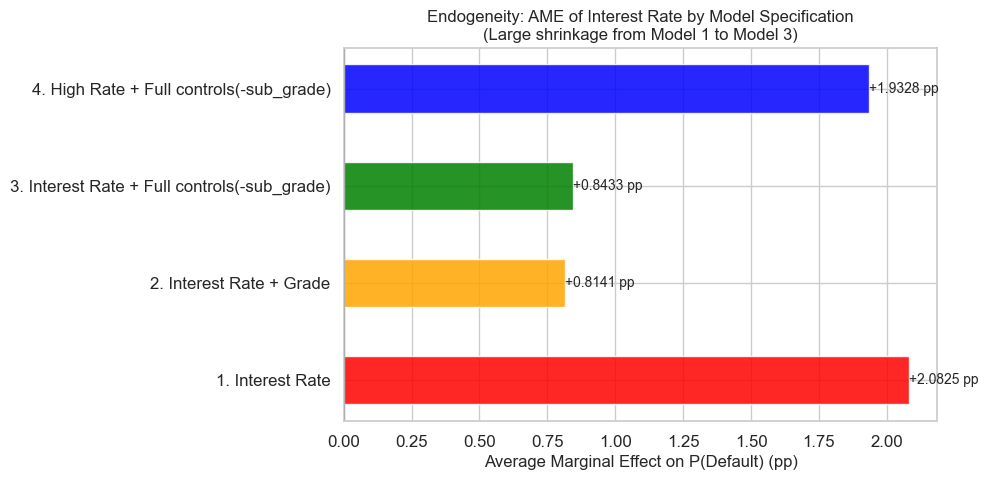

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
models  = results['Model'].tolist()
ames    = results['AME (pp)'].tolist()
colors  = ['red', 'orange', 'green', 'blue']

bars = ax.barh(models, ames, color=colors, alpha=0.85, edgecolor='white', height=0.5)
for bar, ame in zip(bars, ames):
    ax.text(ame + 0.001, bar.get_y() + bar.get_height()/2,
            f'{ame:+.4f} pp', va='center', fontsize=10)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Average Marginal Effect on P(Default) (pp)', fontsize=12)
ax.set_title('Endogeneity: AME of Interest Rate by Model Specification\n'
             '(Large shrinkage from Model 1 to Model 3)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig15_endogeneity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Within-Grade Naive Estimates

The within-grade regressions show that the marginal effect of interest rates on default increases substantially for lower credit grades, suggesting that high-risk borrowers are significantly more sensitive to interest rates.

Causal identification of the interest rate effect requires within-grade variation because credit grades largely summarize borrower risk and strongly determine loan pricing. If interest rates were almost constant within each grade, it would be impossible to distinguish whether higher default rates are driven by pricing itself or by underlying risk differences across grades.

The second plot shows that the standard deviation of interest rates within each grade is meaningfully positive, indicating sufficient dispersion in pricing among borrowers with similar observable risk. This within-grade variation provides the necessary local comparisons to credibly estimate the causal impact of loan pricing on default.

In [43]:
GRADE_ORDER = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
sub_grades = [f"{g}{i}" for g in GRADE_ORDER for i in range(1, 6)]
decode_map = {i: val for i, val in enumerate(sub_grades)}

wg_rows = []
for grade in GRADE_ORDER:
    sub = mdf[mdf['subgrade_num'].map(decode_map).str.startswith(grade)].copy()
    if len(sub) < 200: 
        continue
    try:
        m = sm.Logit(sub['default'], sm.add_constant(sub[['int_rate']])).fit(disp=False)
        ame = m.get_margeff().summary_frame().loc['int_rate', 'dy/dx']
        wg_rows.append({
            'grade': grade,
            'n': len(sub),
            'default_rate': sub['default'].mean(),
            'mean_rate': sub['int_rate'].mean(),
            'rate_std': sub['int_rate'].std(),
            'AME_pp': ame * 100,
            'p_value': m.pvalues['int_rate']
        })
    except Exception as e:
        print(f'Grade {grade}: {e}')

wg_df = pd.DataFrame(wg_rows)
print('Within-grade naive logistic: default ~ int_rate | grade')
print(wg_df.round(4).to_string(index=False))

Within-grade naive logistic: default ~ int_rate | grade
grade      n  default_rate  mean_rate  rate_std  AME_pp  p_value
    A 174341        0.0591     7.0968    1.0042  1.6896      0.0
    B 299820        0.1319    10.5834    1.3660  0.7670      0.0
    C 291840        0.2225    13.9105    1.2075  0.6780      0.0
    D 153978        0.3064    17.4832    1.3647  0.9061      0.0
    E  74312        0.3934    20.6178    1.8571  0.4207      0.0
    F  25356        0.4624    24.4325    1.6496  1.9144      0.0
    G   6270        0.5116    27.0403    1.6706  3.6123      0.0


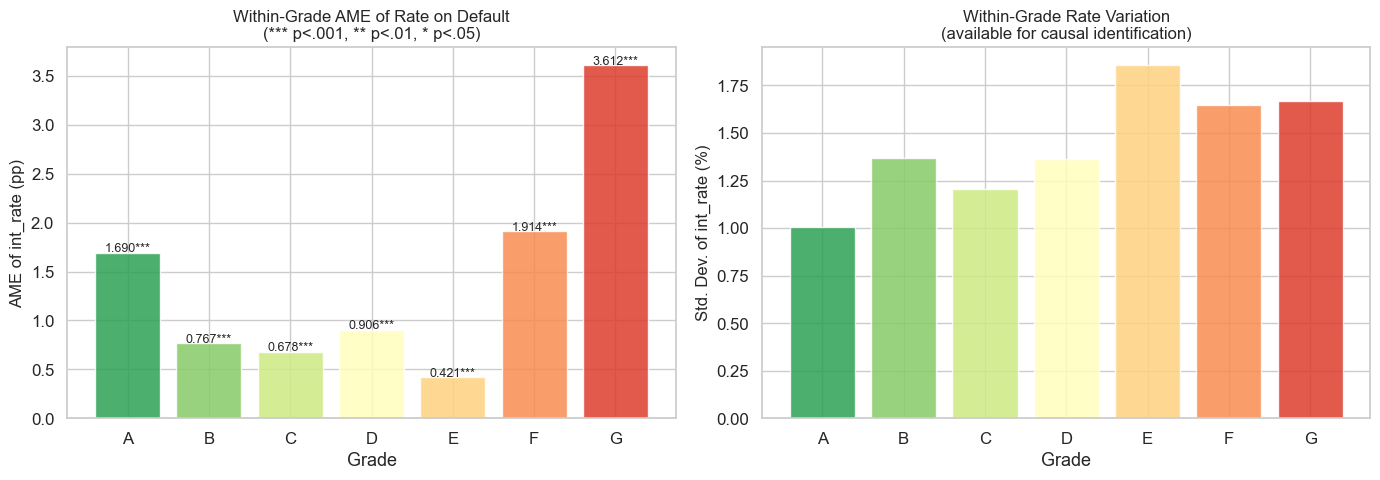

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gp = sns.color_palette('RdYlGn_r', n_colors=len(wg_df))

ax = axes[0]
bars = ax.bar(wg_df['grade'], wg_df['AME_pp'], color=gp, alpha=0.85, edgecolor='white')
for bar, row in zip(bars, wg_df.itertuples()):
    sig = '***' if row.p_value < 0.001 else '**' if row.p_value < 0.01 else '*' if row.p_value < 0.05 else ''
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row.AME_pp:.3f}{sig}', ha='center', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Grade', fontsize=13); ax.set_ylabel('AME of int_rate (pp)', fontsize=12)
ax.set_title('Within-Grade AME of Rate on Default\n(*** p<.001, ** p<.01, * p<.05)', fontsize=12)

ax = axes[1]
ax.bar(wg_df['grade'], wg_df['rate_std'], color=gp, alpha=0.85, edgecolor='white')
ax.set_xlabel('Grade', fontsize=13); ax.set_ylabel('Std. Dev. of int_rate (%)', fontsize=12)
ax.set_title('Within-Grade Rate Variation\n(available for causal identification)', fontsize=12)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig16_within_grade_effects.png', dpi=150, bbox_inches='tight')
plt.show()

## Frisch–Waugh–Lovell Decomposition

Frisch–Waugh–Lovell (FWL) decomposition shows that the treatment coefficient in a regression with controls can be obtained by first removing the variation explained by the controls from both the treatment and the outcome, and then relating the remaining residual variation.

In our results, the coefficient drops substantially after residualizing (from about 0.017 to 0.006), indicating that roughly 66% of the naive association between high rates and default is explained by observable borrower risk factors, consistent with risk-based pricing and confounding.

In [47]:
# FWL: the OLS coefficient on T in Y ~ T + X equals
# OLS of residualized Y on residualized T.
# Compares naive coefficient vs. after-controls coefficient in linear probability terms.

X_ctrl = mdf[COVARIATES].fillna(0).astype(float)

T_resid = mdf['high_rate'].values - LinearRegression().fit(X_ctrl, mdf['high_rate']).predict(X_ctrl)
Y_resid = mdf['default'].values  - LinearRegression().fit(X_ctrl, mdf['default']).predict(X_ctrl)

fwl_coef   = np.cov(T_resid, Y_resid, ddof=0)[0, 1] / np.var(T_resid, ddof=0)
naive_coef = (np.cov(mdf['high_rate'], mdf['default'], ddof=0)[0, 1] /
              np.var(mdf['high_rate'], ddof=0))

pct_explained = (1 - abs(fwl_coef) / abs(naive_coef)) * 100

print('=== FRISCH–WAUGH–LOVELL DECOMPOSITION ===')
print(f'OLS coef — naive           : {naive_coef:.6f}')
print(f'OLS coef — residualized FWL: {fwl_coef:.6f}')
print(f'Explained by controls      : {pct_explained:.1f}%')
print()
print(f'Observable controls account for {pct_explained:.0f}% of the naive coefficient.')
print('The remaining residual motivates propensity score and DML in Notebook 04.')

=== FRISCH–WAUGH–LOVELL DECOMPOSITION ===
OLS coef — naive           : 0.017073
OLS coef — residualized FWL: 0.005806
Explained by controls      : 66.0%

Observable controls account for 66% of the naive coefficient.
The remaining residual motivates propensity score and DML in Notebook 04.


## Cross-Validated AUC

In [51]:
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y   = mdf['default'].values

pipe_X = Pipeline([('lr', LogisticRegression(max_iter=300))])
auc_X  = cross_val_score(pipe_X, 
                         mdf[[col for col in COVARIATES if col not in high_VIF]].values, y,
                         cv=cv, 
                         scoring='roc_auc').mean()

full_cols = ['high_rate'] + [col for col in COVARIATES if col not in high_VIF]
pipe_full= Pipeline([('lr', LogisticRegression(max_iter=500))])
auc3_full = cross_val_score(pipe_full, 
                            mdf[full_cols].values, y,
                            cv=cv, 
                            scoring='roc_auc').mean()

print('5-Fold CV AUC:')
print(f'  Default ~ X only                : {auc_X:.4f}')
print(f'  Default ~ high_rate + X         : {auc3_full:.4f}')
print(f'  Gain from adding high_rate      : {auc3_full - auc_X:.4f}')
print()
print('Near 0 AUC gain = relative loan pricing provides little incremental predictive power ')
print('                  beyond observable borrower risk characteristics.')

5-Fold CV AUC:
  Default ~ X only                : 0.7172
  Default ~ high_rate + X         : 0.7181
  Gain from adding high_rate      : 0.0009

Near 0 AUC gain = relative loan pricing provides little incremental predictive power 
                  beyond observable borrower risk characteristics.


## Summary

**Endogeneity findings**:
- The naive logistic AME substantially overstates the causal effect. Adding grade fixed effects and full observable controls causes a large shrinkage.
- The FWL decomposition shows that a large fraction of the raw coefficient is absorbed by observables.
- Residual bias likely remains (lenders observe soft data, proprietary scores) → motivates propensity score and DML in Notebook 04.

**Within-grade variation**:
- Rate standard deviation within each grade is 1–3 pp — sufficient for identification.
- The within-grade raw rate–default association is positive and significant across all grades.